---
#mySQL資料分析，side project 3：

學號：111570039

姓名：林子茵

#1.題目：你是A公司的新進sql數據分析師，請你從各個角度分析A公司1996～1998年的各種業務數據，從中來評估A公司的：
#【員工能力評估、員工銷售績效分析】、
#【客群分析（國家客群、客戶購買力、活躍客戶）】、
#【熱門銷售產品分析、受喜愛產品分析】、
#【逐年逐月業績分析】
#最後請寫份摘要報告。請多用定量描述的方式，來證明你分析觀點的可靠性、準確性與權威性，以建立個人數據分析的品牌與形象。

---
#2.需要安裝新的資料庫：company2 企業內部業務資料庫，請自行下載安裝到workbench到你的local資料庫
https://acupun.site/lecture/sql/example/sql/company2-edit01.zip

安裝時，下面的選項不用修改，直接OK安裝

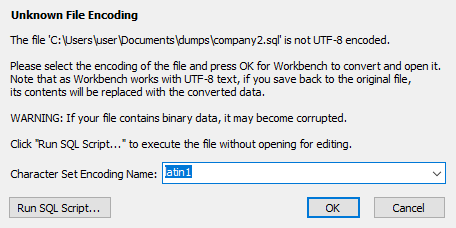


#**注意：訂單明細【Order Details】，要寫成：’Order Details'，要前後加上反引號**

期限：2週


---
#安裝mysql的python的驅動程式碼

In [ ]:
!pip install pymysql

---
#連線第1個資料庫：company2企業內部業務資料庫

#會員user1
密碼：123@Ntut

資料庫：company2

Azure主機：ccw-mysql.mysql.database.azure.com

In [ ]:
#連線Azure mysql資料庫指令
import pymysql
conn = pymysql.connect(
      host="ccw-mysql.mysql.database.azure.com",
      user="user1",
      password="123@Ntut",
      database="company2")

---
# 1.第1題：找出未曾下單的客戶資料
#目的：找出本公司的待開發之潛在客戶

In [ ]:
import pandas as pd
sql = '''
select customers.CustomerID,customers.CompanyName,customers.ContactName from customers
where not exists
  (select * from orders
	  where customers.CustomerID=orders.CustomerID);
'''
df = pd.read_sql_query(sql, conn)
df

<ipython-input-5-6a3b3f968bc3>:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


,CustomerID,CompanyName,ContactName
0,FISSA,FISSA Fabrica Inter. Salchichas S.A.,Diego Roel
1,PARIS,Paris spcialits,Marie Bertrand
2,Val2,IT,Val2
3,VALON,IT,Valon Hoti


---
# 2.第2題：根據訂單數量為產品分類
若產品的訂單數量<10，則標示『銷量差』

若產品的訂單數量<=20 而且>=10，則標示『銷量普通』

若產品的訂單數量>20，則標示『銷量好』
#目的：將本公司產品，進行分類【銷量差，銷量普通，銷量好】

In [ ]:
sql = '''
select
products.ProductID,products.ProductName,
if(count(`order details`.ProductID)>20,
	'銷量好',
	if(count(`order details`.ProductID)<10,'銷量差','銷量普通')) 產品銷量等級
from `order details`,products
	where products.ProductID=`order details`.ProductID
    group by products.ProductID;
'''
df = pd.read_sql_query(sql, conn)
df

<ipython-input-35-ac0aec8111d9>:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


,ProductID,ProductName,產品銷量等級
0,1,Chai,銷量好
1,2,Chang,銷量好
2,3,Aniseed Syrup,銷量普通
3,4,Chef Anton's Cajun Seasoning,銷量普通
4,5,Chef Anton's Gumbo Mix,銷量普通
...,...,...,...
72,73,Rd Kaviar,銷量普通
73,74,Longlife Tofu,銷量普通
74,75,Rhnbru Klosterbier,銷量好
75,76,Lakkalikri,銷量好


---
# 3.第3題：根據銷售金額，對員工進行排名
#目的：找出表現好的員工並予以嘉獎，也找出表現差的員工，先輔導，再不行則辭退
不需要考慮【Order Details】裡面的Discount

#**注意：訂單明細【Order Details】，要寫成：’Order Details'，要前後加上反引號**

In [ ]:
sql = '''
select orders.EmployeeID,employees.FirstName,employees.LastName,
	   rank() over (order by sum(`order details`.UnitPrice*`order details`.Quantity) desc) 銷售排名
from orders
	join `order details`
		on orders.OrderID=`order details`.OrderID
	join employees
		on employees.EmployeeID=orders.EmployeeID
	group by orders.EmployeeID;
'''
df = pd.read_sql_query(sql, conn)
df

<ipython-input-24-c89fbafc5c56>:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


,EmployeeID,FirstName,LastName,銷售排名
0,4,Margaret,Peacock,1
1,3,Janet,Leverling,2
2,1,Nancy,Davolio,3
3,2,Andrew,Fuller,4
4,7,Robert,King,5
5,8,Laura,Callahan,6
6,9,Anne,Dodsworth,7
7,6,Michael,Suyama,8
8,5,Steven,Buchanan,9


---
# 4.第4題：根據國家來統計客戶數量
#目的：評估本公司海外客戶，哪些國家是主要客群

In [ ]:
sql = '''
select Country,count(Country) 客戶數量 from customers
	group by Country;
'''
df = pd.read_sql_query(sql, conn)
df

<ipython-input-25-759208d4c263>:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


,Country,客戶數量
0,Germany,11
1,Mexico,5
2,UK,7
3,Sweden,2
4,France,11
5,Spain,5
6,Canada,3
7,Argentina,3
8,Switzerland,2
9,Brazil,9


---
# 5.第5題：找出至少下過5個訂單的客戶

#目的：找出本公司的活躍客戶，不斷重複下單

In [ ]:
sql = '''
select customers.CustomerID,customers.CompanyName,count(orders.CustomerID) as 下單次數 from customers
  join orders
	  on customers.CustomerID=orders.CustomerID
  group by customers.CompanyName,customers.CustomerID
  having count(orders.CustomerID) >= 5;
'''
df = pd.read_sql_query(sql, conn)
df

<ipython-input-34-797d2affde23>:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


,CustomerID,CompanyName,下單次數
0,ALFKI,Alfreds Futterkiste,6
1,ANTON,Antonio Moreno Taquera,7
2,AROUT,Around the Horn,13
3,BSBEV,B's Beverages,10
4,BERGS,Berglunds snabbkp,18
...,...,...,...
68,WARTH,Wartian Herkku,15
69,WELLI,Wellington Importadora,9
70,WHITC,White Clover Markets,14
71,WILMK,Wilman Kala,7


---
#6.第6題：計算每個產品類別銷售額，佔總銷售額的百分比
#目的：分析本公司各類產品，哪些是佔營收大宗的主要銷售大類？
不需要考慮【Order Details】裡面的Discount

#**注意：訂單明細【Order Details】，要寫成：’Order Details'，要前後加上反引號**

In [ ]:
sql = '''
select categories.CategoryID,categories.CategoryName,
	   round(
       sum(`order details`.UnitPrice*`order details`.Quantity)
       /
       (select sum(`order details`.UnitPrice*`order details`.Quantity) from `order details`)
       *100,6) 佔比
from products
	join categories
		on categories.CategoryID=products.CategoryID
	join `order details`
		on `order details`.ProductID=products.ProductID
	group by categories.CategoryID;
'''
df = pd.read_sql_query(sql, conn)
df

<ipython-input-27-3c3bbf338d42>:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


,CategoryID,CategoryName,佔比
0,1,Beverages,21.154353
1,2,Condiments,8.394110
2,3,Confections,13.075269
3,4,Dairy Products,18.555791
4,5,Grains/Cereals,7.436684
5,6,Meat/Poultry,13.155722
6,7,Produce,7.772006
7,8,Seafood,10.456066


---
# 7.第7題：製作不同員工，在不同國家的訂單數量分析表
#目的：評估不同員工，對不同國家的銷售能力

In [ ]:
sql = '''
select distinct
	employees.FirstName,employees.LastName,orders.ShipCountry
  ,count(orders.ShipCountry) 訂單數量
from employees
    join orders
		  on orders.EmployeeID=employees.EmployeeID
	  group by
		  employees.FirstName,orders.ShipCountry,employees.LastName;
'''
df = pd.read_sql_query(sql, conn)
df

<ipython-input-28-4e4a920e74c6>:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


,FirstName,LastName,ShipCountry,訂單數量
0,Nancy,Davolio,Austria,5
1,Nancy,Davolio,Finland,2
2,Nancy,Davolio,Italy,5
3,Nancy,Davolio,Germany,19
4,Nancy,Davolio,Brazil,11
...,...,...,...,...
162,Anne,Dodsworth,Venezuela,1
163,Anne,Dodsworth,Finland,1
164,Anne,Dodsworth,Argentina,2
165,Anne,Dodsworth,Portugal,1


---
# 8.第8題：找出所有訂單中最昂貴單價的前5個產品
#目的：評估本公司有被下訂的產品，哪些的CP值高（單價高，又有人買）

In [ ]:
sql = '''
select ProductID,ProductName,round(UnitPrice,2) 最昂貴價錢 from products
	order by UnitPrice desc
    limit 5;
'''
df = pd.read_sql_query(sql, conn)
df

<ipython-input-20-42a141aeea38>:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


,ProductID,ProductName,最昂貴價錢
0,38,Cte de Blaye,263.50
1,29,Thringer Rostbratwurst,123.79
2,9,Mishi Kobe Niku,97.00
3,20,Sir Rodney's Marmalade,81.00
4,18,Carnarvon Tigers,62.50


---
# 9.第9題：找出所有訂單中還未發貨的訂單資料

In [ ]:
sql = '''
select OrderID,CustomerID,OrderDate,ShippedDate from orders
	where ShippedDate is null;
'''
df = pd.read_sql_query(sql, conn)
df

<ipython-input-19-c79ce23ddf72>:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


,OrderID,CustomerID,OrderDate,ShippedDate
0,11008,ERNSH,1998-04-08,None
1,11019,RANCH,1998-04-13,None
2,11039,LINOD,1998-04-21,None
3,11040,GREAL,1998-04-22,None
4,11045,BOTTM,1998-04-23,None
5,11051,LAMAI,1998-04-27,None
6,11054,CACTU,1998-04-28,None
7,11058,BLAUS,1998-04-29,None
8,11059,RICAR,1998-04-29,None
9,11061,GREAL,1998-04-30,None


---
# 10.第10題：顯示每個客戶的平均訂單金額，請依照平均訂單金額排序
#目的：評估每個客戶的購買能力，從此來評估哪些客戶是有購買力的大客戶（富豪）

不需要考慮【Order Details】裡面的Discount


#**注意：訂單明細【Order Details】，要寫成：’Order Details'，要前後加上反引號**

In [ ]:
sql = '''
select
	customers.CustomerID,customers.CompanyName,
    round(sum(UnitPrice*Quantity)/count(orders.OrderID),6) 平均訂單金額
from orders
	join `order details`
		on orders.OrderID=`order details`.OrderID
    join customers
		on orders.CustomerID=customers.CustomerID
	group by orders.CustomerID
    order by 平均訂單金額 desc;
'''
df = pd.read_sql_query(sql, conn)
df

<ipython-input-18-51b955b31694>:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


,CustomerID,CompanyName,平均訂單金額
0,QUICK,QUICK-Stop,1366.085930
1,SIMOB,Simons bistro,1209.230000
2,PICCO,Piccolo und mehr,1141.736957
3,ERNSH,Ernst Handel,1110.163529
4,HANAR,Hanari Carnes,1065.660938
...,...,...,...
84,NORTS,North/South,108.166667
85,ROMEY,Romero y tomillo,104.806429
86,GALED,Galera del gastrnomo,104.587500
87,LAUGB,Laughing Bacchus Wine Cellars,65.312500


---
# 11.第11題：統計每個類別下的產品數量。

In [ ]:
sql = '''
select CategoryName,count(categories.CategoryID) 產品數量 from products
	join categories
		on products.CategoryID=categories.CategoryID
	group by CategoryName;
'''
df = pd.read_sql_query(sql, conn)
df

<ipython-input-14-ca8078f43482>:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


,CategoryName,產品數量
0,Beverages,12
1,Condiments,12
2,Confections,13
3,Dairy Products,10
4,Grains/Cereals,7
5,Meat/Poultry,6
6,Produce,5
7,Seafood,12


---
# 12.第12題：找出銷售總額低於平均水準的員工
#找出需要再教育訓練，需要再加強行銷能力的員工
不需要考慮【Order Details】裡面的Discount

#**注意：訂單明細【Order Details】，要寫成：’Order Details'，要前後加上反引號**


In [ ]:
sql = '''
select
	orders.EmployeeID,employees.FirstName,employees.LastName,
    sum(UnitPrice*Quantity) 銷售總額
from orders
	join `order details`
		on orders.OrderID=`order details`.OrderID
	join employees
		on employees.EmployeeID=orders.EmployeeID
	group by employees.EmployeeID
    having sum(UnitPrice*Quantity)
		   <
           (select sum(UnitPrice*Quantity)
           /
           (select count(EmployeeID) from employees)
           from `order details`);
'''
df = pd.read_sql_query(sql, conn)
df

<ipython-input-13-cc8246fd46ed>:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


,EmployeeID,FirstName,LastName,銷售總額
0,5,Steven,Buchanan,75567.75
1,6,Michael,Suyama,78198.10
2,7,Robert,King,141295.99
3,8,Laura,Callahan,133301.03
4,9,Anne,Dodsworth,82964.00


---
# 13.第13題：顯示所有訂單的總銷售額
不需要考慮【Order Details】裡面的Discount


#**注意：訂單明細【Order Details】，要寫成：’Order Details'，要前後加上反引號**

In [ ]:
sql = '''
select round(sum(UnitPrice*Quantity),2) 總銷售額 from `order details`;
'''
df = pd.read_sql_query(sql, conn)
df

<ipython-input-12-ce6bbd3ba0e3>:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


,總銷售額
0,1354458.59


---
# 14.第14題：列出至少有5個不同客戶下訂單的產品
#目的：查詢本公司收客戶歡迎的產品：只要被5個以上客戶下訂，就表示該產品受歡迎


#**注意：訂單明細【Order Details】，要寫成：’Order Details'，要前後加上反引號**

In [ ]:
sql = '''
select
	products.ProductID,products.ProductName,
    count(distinct CustomerID) 客戶下單數
from `order details`
	join products
		on products.ProductID=`order details`.ProductID
	join orders
		on orders.OrderID=`order details`.OrderID
    group by products.ProductID;
'''
df = pd.read_sql_query(sql, conn)
df

<ipython-input-10-d17885cf3b98>:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


,ProductID,ProductName,客戶下單數
0,1,Chai,31
1,2,Chang,28
2,3,Aniseed Syrup,10
3,4,Chef Anton's Cajun Seasoning,17
4,5,Chef Anton's Gumbo Mix,9
...,...,...,...
72,73,Rd Kaviar,11
73,74,Longlife Tofu,11
74,75,Rhnbru Klosterbier,33
75,76,Lakkalikri,33


---
# 15.第15題：找出至少向本公司購買過3種不同產品的客戶資料
#目的：找出本公司的活躍客戶，或喜歡本公司產品的客戶（購買多種產品）

#**注意：訂單明細【Order Details】，要寫成：’Order Details'，要前後加上反引號**

In [ ]:
sql = '''
select
	orders.CustomerID,CompanyName,count(distinct ProductID) 購買不同產品數量
from orders
	join `order details`
		on orders.OrderID=`order details`.OrderID
	join customers
		on orders.CustomerID=customers.CustomerID
	group by orders.CustomerID;
'''
df = pd.read_sql_query(sql, conn)
df

<ipython-input-9-d40cc1582e64>:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


,CustomerID,CompanyName,購買不同產品數量
0,ALFKI,Alfreds Futterkiste,11
1,ANATR,Ana Trujillo Emparedados y helados,10
2,ANTON,Antonio Moreno Taquera,15
3,AROUT,Around the Horn,24
4,BERGS,Berglunds snabbkp,37
...,...,...,...
84,WARTH,Wartian Herkku,28
85,WELLI,Wellington Importadora,16
86,WHITC,White Clover Markets,32
87,WILMK,Wilman Kala,17


---
# 16.第16題：統計每年，每個月的訂單數量
#目的：可以看出逐年逐月的銷售趨勢

In [ ]:
sql = '''
select
	year(OrderDate) 年,month(OrderDate) 月,count(year(OrderDate)) 訂單總量
from orders
	group by year(OrderDate),month(OrderDate);
'''
df = pd.read_sql_query(sql, conn)
df

<ipython-input-8-cfdf8ef24368>:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, conn)


,年,月,訂單總量
0,1996,7,22
1,1996,8,25
2,1996,9,23
3,1996,10,26
4,1996,11,25
5,1996,12,31
6,1997,1,33
7,1997,2,29
8,1997,3,30
9,1997,4,31


---
# 100.關閉連線

In [ ]:
#關閉連線
#conn.close()